# utils

In [1]:
import pandas as pd

def coefficient_of_variation(x):
    return x.std() / x.mean() if x.mean() != 0 else 0

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### to merge multiple files

In [2]:
import pandas as pd
# 개별 CSV 파일 읽기
df1 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_2025-04-24/vllm_offline_nps4_cc_2025-04-24.csv")
df2 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_only_512_and_1024_2025-04-16/vllm_offline_nps4_cc_2025-04-16.csv")
df3 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_only_2048_2025-04-21/vllm_offline_nps4_cc_2025-04-21.csv")

# 리스트에 추가
df_list = [df1, df2, df3]

# 병합
merged_df = pd.concat(df_list, ignore_index=True)

output_csv = "/localdata2/esp/0404/request/0506_offline_cc.csv"
# 저장
merged_df.to_csv(output_csv, index=False)


FileNotFoundError: [Errno 2] No such file or directory: '/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_2025-04-24/vllm_offline_nps4_cc_2025-04-24.csv'

# SGLang TDX 3B model

In [3]:
import pandas as pd
# 개별 CSV 파일 읽기
df1 = pd.read_csv("./intel/sglang_offline_nps4_noncc_5000_2025-12-09/sglang_offline_nps4_noncc_2025-12-09.csv")
df2 = pd.read_csv("./intel/sglang_offline_nps4_noncc_5000_2025-12-08/sglang_offline_nps4_noncc_2025-12-08.csv")
#df3 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_only_2048_2025-04-21/vllm_offline_nps4_cc_2025-04-21.csv")

# 리스트에 추가
df_list = [df1, df2]

# 병합
merged_df = pd.concat(df_list, ignore_index=True)

output_csv = "sglang_offline_noncc_merged.csv"
# 저장
merged_df.to_csv(output_csv, index=False)


In [4]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("sglang_offline_noncc_merged.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_noncc='mean',
    min_noncc='min',
    max_noncc='max',
    std_dev_noncc='std',
    cv_noncc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("sglang_tdx_offline_noncc_3b_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                                     model_path  max_num_seqs  mean_noncc  \
0                      meta-llama/Llama-3.2-3B             1     386.550   
1                      meta-llama/Llama-3.2-3B             2     753.720   
2                      meta-llama/Llama-3.2-3B             4    1501.505   
3                      meta-llama/Llama-3.2-3B             8    2925.010   
4                      meta-llama/Llama-3.2-3B            16    5385.095   
5                      meta-llama/Llama-3.2-3B            32    9813.805   
6                      meta-llama/Llama-3.2-3B            64   16513.055   
7                      meta-llama/Llama-3.2-3B           128   24325.520   
8                      meta-llama/Llama-3.2-3B           256   28585.605   
9                      meta-llama/Llama-3.2-3B           512   34356.830   
10                     meta-llama/Llama-3.2-3B          1024   29770.720   
11                     meta-llama/Llama-3.2-3B          20

In [5]:
import pandas as pd
# 개별 CSV 파일 읽기
df1 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-12-09/sglang_offline_nps4_cc_2025-12-09.csv")
df2 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-12-09/sglang_offline_nps4_cc_1.csv")
#df3 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_only_2048_2025-04-21/vllm_offline_nps4_cc_2025-04-21.csv")

# 리스트에 추가
df_list = [df1, df2]

# 병합
merged_df = pd.concat(df_list, ignore_index=True)

output_csv = "sglang_offline_cc_merged.csv"
# 저장
merged_df.to_csv(output_csv, index=False)


In [6]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("sglang_offline_cc_merged.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_cc='mean',
    min_cc='min',
    max_cc='max',
    std_dev_cc='std',
    cv_cc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("sglang_tdx_offline_cc_3b_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                  model_path  max_num_seqs    mean_cc    min_cc    max_cc  \
0   meta-llama/Llama-3.2-3B             1    249.580    248.69    250.47   
1   meta-llama/Llama-3.2-3B             2    476.275    472.98    479.57   
2   meta-llama/Llama-3.2-3B             4    946.540    918.63    974.45   
3   meta-llama/Llama-3.2-3B             8   1831.960   1774.99   1888.93   
4   meta-llama/Llama-3.2-3B            16   3324.605   3271.31   3377.90   
5   meta-llama/Llama-3.2-3B            32   5946.300   5898.90   5993.70   
6   meta-llama/Llama-3.2-3B            64   9949.870   9725.14  10174.60   
7   meta-llama/Llama-3.2-3B           128  15681.210  15490.47  15871.95   
8   meta-llama/Llama-3.2-3B           256  17266.970  17247.50  17286.44   
9   meta-llama/Llama-3.2-3B           512  25880.345  25777.99  25982.70   
10  meta-llama/Llama-3.2-3B          1024  28044.150  27753.92  28334.38   
11  meta-llama/Llama-3.2-3B          2048  27294.075  2544

In [39]:
import pandas as pd

# 두 개의 CSV 파일 읽기
df1 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/sglang_tdx_offline_cc_3b_min_and_max.csv")
df2 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/sglang_tdx_offline_noncc_3b_min_and_max.csv")

sglang_tdx_3b_df = pd.merge(df1, df2, on=['model_path', 'max_num_seqs'], how='inner')
# cc_overhead 열 추가: mean_noncc / mean_cc
sglang_tdx_3b_df['cc_overhead'] = sglang_tdx_3b_df['mean_noncc'] / sglang_tdx_3b_df['mean_cc']
sglang_tdx_3b_df['min_cc_overhead'] = sglang_tdx_3b_df['min_noncc'] / sglang_tdx_3b_df['min_cc']
sglang_tdx_3b_df['max_cc_overhead'] = sglang_tdx_3b_df['max_noncc'] / sglang_tdx_3b_df['max_cc']
# 결과 확인
#print(sglang_tdx_3b_df[['model_path', 'max_num_seqs', 'mean_noncc', 'mean_cc', 'cc_overhead']].head())
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(sglang_tdx_3b_df.columns)
display(sglang_tdx_3b_df[['model_path','max_num_seqs','mean_cc','mean_noncc','cv_cc','cv_noncc','cc_overhead']])

Index(['model_path', 'max_num_seqs', 'mean_cc', 'min_cc', 'max_cc',
       'std_dev_cc', 'cv_cc', 'mean_noncc', 'min_noncc', 'max_noncc',
       'std_dev_noncc', 'cv_noncc', 'cc_overhead', 'min_cc_overhead',
       'max_cc_overhead'],
      dtype='object')


,model_path,max_num_seqs,mean_cc,mean_noncc,cv_cc,cv_noncc,cc_overhead
0,meta-llama/Llama-3.2-3B,1,249.580,386.550,0.005043,0.000512,1.548802
1,meta-llama/Llama-3.2-3B,2,476.275,753.720,0.009784,0.000356,1.582531
2,meta-llama/Llama-3.2-3B,4,946.540,1501.505,0.041700,0.000786,1.586309
3,meta-llama/Llama-3.2-3B,8,1831.960,2925.010,0.043979,0.000624,1.596656
4,meta-llama/Llama-3.2-3B,16,3324.605,5385.095,0.022671,0.000311,1.619770
5,meta-llama/Llama-3.2-3B,32,5946.300,9813.805,0.011273,0.001230,1.650405
6,meta-llama/Llama-3.2-3B,64,9949.870,16513.055,0.031942,0.001433,1.659625
7,meta-llama/Llama-3.2-3B,128,15681.210,24325.520,0.017202,0.003430,1.551253
8,meta-llama/Llama-3.2-3B,256,17266.970,28585.605,0.001595,0.056289,1.655508
9,meta-llama/Llama-3.2-3B,512,25880.345,34356.830,0.005593,0.009166,1.327526


# vLLM TDX 3B model

In [5]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("./intel/vllm_offline_nps4_v1_cc_5000_2025-12-08/vllm_offline_nps4_cc_2025-12-08.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_cc='mean',
    min_cc='min',
    max_cc='max',
    std_dev_cc='std',
    cv_cc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("vllm_tdx_offline_cc_3b_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                  model_path  max_num_seqs       mean_cc    min_cc    max_cc  \
0   meta-llama/Llama-3.2-3B             1    304.780000    304.73    304.83   
1   meta-llama/Llama-3.2-3B             2    604.000000    596.33    611.67   
2   meta-llama/Llama-3.2-3B             4   1179.693333   1159.86   1193.56   
3   meta-llama/Llama-3.2-3B             8   2282.560000   2264.66   2318.34   
4   meta-llama/Llama-3.2-3B            16   4220.486667   4132.89   4307.06   
5   meta-llama/Llama-3.2-3B            32   7557.276667   7475.97   7694.90   
6   meta-llama/Llama-3.2-3B            64  12248.996667  12053.73  12559.07   
7   meta-llama/Llama-3.2-3B           128  18086.676667  17710.53  18275.37   
8   meta-llama/Llama-3.2-3B           256  23126.890000  22803.23  23526.18   
9   meta-llama/Llama-3.2-3B           512  24659.156667  23898.27  25285.42   
10  meta-llama/Llama-3.2-3B          1024  26161.983333  25408.72  26989.05   
11  meta-llama/Llama-3

In [8]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("./intel/vllm_offline_nps4_v1_noncc_5000_2025-12-08/vllm_offline_nps4_noncc_2025-12-08.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_noncc='mean',
    min_noncc='min',
    max_noncc='max',
    std_dev_noncc='std',
    cv_noncc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("vllm_tdx_offline_noncc_3b_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                                     model_path  max_num_seqs  mean_noncc  \
0                      meta-llama/Llama-3.2-3B             1     336.120   
1                      meta-llama/Llama-3.2-3B             2     666.750   
2                      meta-llama/Llama-3.2-3B             4    1301.075   
3                      meta-llama/Llama-3.2-3B             8    2537.265   
4                      meta-llama/Llama-3.2-3B            16    4660.820   
5                      meta-llama/Llama-3.2-3B            32    8327.650   
6                      meta-llama/Llama-3.2-3B            64   13545.175   
7                      meta-llama/Llama-3.2-3B           128   19879.045   
8                      meta-llama/Llama-3.2-3B           256   25372.200   
9                      meta-llama/Llama-3.2-3B           512   26737.485   
10                     meta-llama/Llama-3.2-3B          1024   28740.915   
11                     meta-llama/Llama-3.2-3B          20

In [3]:
import pandas as pd

# 두 개의 CSV 파일 읽기
df1 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/vllm_tdx_offline_cc_3b_min_and_max.csv")
df2 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/vllm_tdx_offline_noncc_3b_min_and_max.csv")

vllm_tdx_3b_df = pd.merge(df1, df2, on=['model_path', 'max_num_seqs'], how='inner')
# cc_overhead 열 추가: mean_noncc / mean_cc
vllm_tdx_3b_df['cc_overhead'] = vllm_tdx_3b_df['mean_noncc'] / vllm_tdx_3b_df['mean_cc']
vllm_tdx_3b_df['min_cc_overhead'] = vllm_tdx_3b_df['min_noncc'] / vllm_tdx_3b_df['min_cc']
vllm_tdx_3b_df['max_cc_overhead'] = vllm_tdx_3b_df['max_noncc'] / vllm_tdx_3b_df['max_cc']
# 결과 확인
#print(vllm_tdx_3b_df[['model_path', 'max_num_seqs', 'mean_noncc', 'mean_cc', 'cc_overhead']].head())
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(vllm_tdx_3b_df.columns)
display(vllm_tdx_3b_df[['model_path','max_num_seqs','mean_cc','mean_noncc','cv_cc','cv_noncc','cc_overhead']])

Index(['model_path', 'max_num_seqs', 'mean_cc', 'min_cc', 'max_cc',
       'std_dev_cc', 'cv_cc', 'mean_noncc', 'min_noncc', 'max_noncc',
       'std_dev_noncc', 'cv_noncc', 'cc_overhead', 'min_cc_overhead',
       'max_cc_overhead'],
      dtype='object')


,model_path,max_num_seqs,mean_cc,mean_noncc,cv_cc,cv_noncc,cc_overhead
0,meta-llama/Llama-3.2-3B,1,304.780000,336.120,0.000232,0.001052,1.102828
1,meta-llama/Llama-3.2-3B,2,604.000000,666.750,0.017959,0.000318,1.103891
2,meta-llama/Llama-3.2-3B,4,1179.693333,1301.075,0.014940,0.003897,1.102893
3,meta-llama/Llama-3.2-3B,8,2282.560000,2537.265,0.013575,0.000844,1.111587
4,meta-llama/Llama-3.2-3B,16,4220.486667,4660.820,0.020635,0.000686,1.104332
5,meta-llama/Llama-3.2-3B,32,7557.276667,8327.650,0.015857,0.005256,1.101938
6,meta-llama/Llama-3.2-3B,64,12248.996667,13545.175,0.022167,0.009750,1.105819
7,meta-llama/Llama-3.2-3B,128,18086.676667,19879.045,0.018011,0.001100,1.099099
8,meta-llama/Llama-3.2-3B,256,23126.890000,25372.200,0.015885,0.007463,1.097087
9,meta-llama/Llama-3.2-3B,512,24659.156667,26737.485,0.028521,0.076876,1.084282


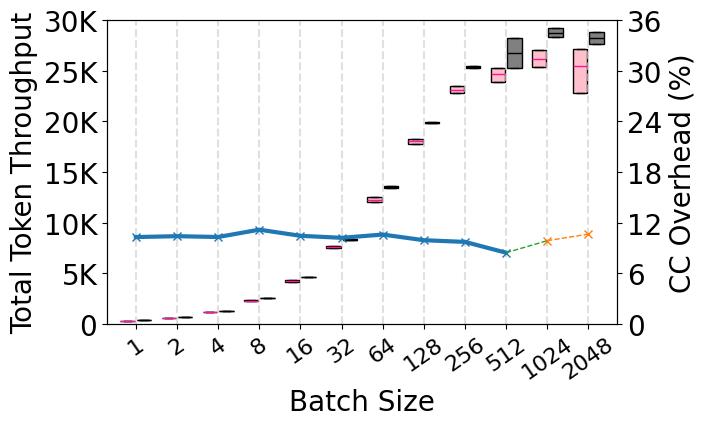

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker


def k_formatter(x, pos):
    if abs(x) < 1e-9:
        return "0"              # 0에는 K 안 붙이기
    return f"{x/1000:.0f}K"      # 혹은 .1f로 소수 한 자리까지
# Single model
model_order = ["meta-llama/Llama-3.2-3B"]

solid_thresholds = {
    model_order[0]: 512,
}

# Create a single figure/axes
fig, ax1 = plt.subplots(figsize=(7.16, 4.6))

model = model_order[0]
model_df = vllm_tdx_3b_df[vllm_tdx_3b_df["model_path"] == model].copy()

# x-axis positions and labels
x_labels = model_df["max_num_seqs"].tolist()
base_pos = list(range(len(x_labels)))

# Build boxplot dicts
cc_boxes = []
noncc_boxes = []
for i in range(len(model_df)):
    cc_boxes.append({
        'med':    model_df.iloc[i]["mean_cc"],
        'q1':     model_df.iloc[i]["min_cc"],
        'q3':     model_df.iloc[i]["max_cc"],
        'whislo': model_df.iloc[i]["min_cc"],
        'whishi': model_df.iloc[i]["max_cc"],
        'fliers': []
    })
    noncc_boxes.append({
        'med':    model_df.iloc[i]["mean_noncc"],
        'q1':     model_df.iloc[i]["min_noncc"],
        'q3':     model_df.iloc[i]["max_noncc"],
        'whislo': model_df.iloc[i]["min_noncc"],
        'whishi': model_df.iloc[i]["max_noncc"],
        'fliers': []
    })

# Offsets for side-by-side boxes
cc_pos = [p - 0.2 for p in base_pos]
noncc_pos = [p + 0.2 for p in base_pos]

# Boxplots
ax1.bxp(
    cc_boxes, positions=cc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="pink"), medianprops=dict(color="deeppink")
)
ax1.bxp(
    noncc_boxes, positions=noncc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="gray"), medianprops=dict(color="black")
)

# X/Y formatting
ax1.set_xticks(base_pos)
ax1.set_xticklabels([str(x) for x in x_labels], rotation=35, fontsize=16)
ax1.xaxis.set_major_locator(ticker.FixedLocator(base_pos))  # prevent auto-skipping
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5000))
ax1.set_ylim(bottom=0, top=30000)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))

ax1.set_ylabel("Total Token Throughput", fontsize=20)
ax1.set_xlabel("Batch Size", fontsize=20)
#ax1.set_title(model.split('/')[-1], fontsize=20, fontweight="bold")
ax1.tick_params(axis='y', labelsize=20)

# Vertical guides
for pos in base_pos:
    ax1.axvline(x=pos, color="lightgray", linestyle="--", alpha=0.7)

# Secondary axis for CC Overhead (%)
ax2 = ax1.twinx()
threshold = solid_thresholds.get(model, 128)

df_solid = model_df[model_df["max_num_seqs"] <= threshold]
df_dashed = model_df[model_df["max_num_seqs"] > threshold]

if not df_solid.empty:
    x_solid = [x_labels.index(x) for x in df_solid["max_num_seqs"]]
    y_solid = (df_solid["cc_overhead"] - 1) * 100
    ax2.plot(x_solid, y_solid, linestyle='-', marker='x', linewidth=3, label="CC Overhead (≤ threshold)")

if not df_dashed.empty:
    x_dashed = [x_labels.index(x) for x in df_dashed["max_num_seqs"]]
    y_dashed = (df_dashed["cc_overhead"] - 1) * 100
    ax2.plot(x_dashed, y_dashed, linestyle='--', marker='x', linewidth=1, label="CC Overhead (> threshold)")

# Connect solid→dashed if both exist
if not df_solid.empty and not df_dashed.empty:
    last_x_solid = x_labels.index(df_solid["max_num_seqs"].max())
    first_x_dashed = x_labels.index(df_dashed["max_num_seqs"].min())
    last_y_solid = ((df_solid[df_solid["max_num_seqs"] == df_solid["max_num_seqs"].max()]["cc_overhead"].values[0]) - 1) * 100
    first_y_dashed = ((df_dashed[df_dashed["max_num_seqs"] == df_dashed["max_num_seqs"].min()]["cc_overhead"].values[0]) - 1) * 100
    ax2.plot([last_x_solid, first_x_dashed], [last_y_solid, first_y_dashed], linestyle="--", linewidth=1)

ax2.set_ylabel("CC Overhead (%)", fontsize=20)
ax2.set_ylim(bottom=0, top=36)
ax2.tick_params(axis='y', labelsize=20)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(6))

# Legends (combine CC/Non-CC boxes + overhead line)
# handles_boxes = [
#     plt.Line2D([], [], color="deeppink", label="CC"),
#     plt.Line2D([], [], color="black", label="Non-CC"),
# ]
# handles_lines, labels_lines = ax2.get_legend_handles_labels()
# all_handles = handles_boxes + handles_lines
# ax1.legend(all_handles, [h.get_label() for h in all_handles], loc='upper center', ncols=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1.10))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# SGLang eager mode TDX

In [4]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-11-25/sglang_offline_discuda_nps4_cc_2025-11-25.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_cc='mean',
    min_cc='min',
    max_cc='max',
    std_dev_cc='std',
    cv_cc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("sglang_tdx_offline_cc_cuda0_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                 model_path  max_num_seqs  mean_cc   min_cc   max_cc  \
0  meta-llama/Llama-3.1-8B             4   313.79   313.79   313.79   
1  meta-llama/Llama-3.1-8B             8   639.27   639.27   639.27   
2  meta-llama/Llama-3.1-8B            16  1251.84  1251.84  1251.84   
3  meta-llama/Llama-3.1-8B            32  2244.57  2244.57  2244.57   

   std_dev_cc  cv_cc  
0         NaN    NaN  
1         NaN    NaN  
2         NaN    NaN  
3         NaN    NaN  >


In [4]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("./intel/sglang_offline_nps4_noncc_5000_2025-11-24/sglang_offline_discuda_nps4_noncc_2025-11-24.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_cc='mean',
    min_cc='min',
    max_cc='max',
    std_dev_cc='std',
    cv_cc=coefficient_of_variation
).reset_index()

# 결과 저장
#grouped.to_csv("sglang_tdx_offline_noncc_cuda0_min_and_max.csv", index=False)
display(grouped)

FileNotFoundError: [Errno 2] No such file or directory: './intel/sglang_offline_nps4_noncc_5000_2025-11-24/sglang_offline_discuda_nps4_noncc_2025-11-24.csv'

# vLLM TDX

In [6]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("intel/vllm_offline_nps4_v1_cc_5000_2025-11-11/vllm_offline_nps4_cc_2025-11-11.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_cc='mean',
    min_cc='min',
    max_cc='max',
    std_dev_cc='std',
    cv_cc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("vllm_tdx_offline_cc_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                  model_path  max_num_seqs       mean_cc    min_cc    max_cc  \
0   meta-llama/Llama-3.1-8B             1    174.533333    174.17    174.96   
1   meta-llama/Llama-3.1-8B             2    347.756667    347.15    348.15   
2   meta-llama/Llama-3.1-8B             4    685.126667    683.56    687.02   
3   meta-llama/Llama-3.1-8B             8   1334.706667   1331.11   1340.62   
4   meta-llama/Llama-3.1-8B            16   2513.696667   2498.60   2532.28   
5   meta-llama/Llama-3.1-8B            32   4496.780000   4458.85   4526.78   
6   meta-llama/Llama-3.1-8B            64   7455.426667   7387.99   7515.61   
7   meta-llama/Llama-3.1-8B           128  11411.783333  11278.84  11517.59   
8   meta-llama/Llama-3.1-8B           256  15097.266667  14981.81  15204.91   
9   meta-llama/Llama-3.1-8B           512  16661.020000  16561.65  16843.03   
10  meta-llama/Llama-3.1-8B          1024  17351.906667  17221.62  17552.42   
11  meta-llama/Llama-3

In [7]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("intel/vllm_offline_nps4_v1_noncc_5000_2025-11-11/vllm_offline_nps4_noncc_2025-11-11.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_noncc='mean',
    min_noncc='min',
    max_noncc='max',
    std_dev_noncc='std',
    cv_noncc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("vllm_tdx_offline_noncc_min_and_max.csv", index=False)
print(grouped.head)

<bound method NDFrame.head of                  model_path  max_num_seqs  mean_noncc  min_noncc  max_noncc  \
0   meta-llama/Llama-3.1-8B             1     191.595     191.45     191.74   
1   meta-llama/Llama-3.1-8B             2     380.595     379.66     381.53   
2   meta-llama/Llama-3.1-8B             4     749.215     748.89     749.54   
3   meta-llama/Llama-3.1-8B             8    1461.720    1457.77    1465.67   
4   meta-llama/Llama-3.1-8B            16    2740.620    2738.93    2742.31   
5   meta-llama/Llama-3.1-8B            32    4955.505    4944.56    4966.45   
6   meta-llama/Llama-3.1-8B            64    8195.670    8167.55    8223.79   
7   meta-llama/Llama-3.1-8B           128   12411.690   12400.53   12422.85   
8   meta-llama/Llama-3.1-8B           256   16230.135   16188.75   16271.52   
9   meta-llama/Llama-3.1-8B           512   17706.460   17680.41   17732.51   
10  meta-llama/Llama-3.1-8B          1024   18445.670   18420.82   18470.52   
11  meta-llama/Llama-3

In [36]:
import pandas as pd

# 두 개의 CSV 파일 읽기
df1 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/vllm_tdx_offline_cc_min_and_max.csv")
df2 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/vllm_tdx_offline_noncc_min_and_max.csv")

vllm_dtx_df = pd.merge(df1, df2, on=['model_path', 'max_num_seqs'], how='inner')
# cc_overhead 열 추가: mean_noncc / mean_cc
vllm_dtx_df['cc_overhead'] = vllm_dtx_df['mean_noncc'] / vllm_dtx_df['mean_cc']
vllm_dtx_df['min_cc_overhead'] = vllm_dtx_df['min_noncc'] / vllm_dtx_df['min_cc']
vllm_dtx_df['max_cc_overhead'] = vllm_dtx_df['max_noncc'] / vllm_dtx_df['max_cc']
# 결과 확인
#print(vllm_dtx_df[['model_path', 'max_num_seqs', 'mean_noncc', 'mean_cc', 'cc_overhead']].head())
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(vllm_dtx_df.columns)
display(vllm_dtx_df[['model_path','max_num_seqs','mean_cc','mean_noncc','cv_cc','cv_noncc','cc_overhead']])

Index(['model_path', 'max_num_seqs', 'mean_cc', 'min_cc', 'max_cc',
       'std_dev_cc', 'cv_cc', 'mean_noncc', 'min_noncc', 'max_noncc',
       'std_dev_noncc', 'cv_noncc', 'cc_overhead', 'min_cc_overhead',
       'max_cc_overhead'],
      dtype='object')


,model_path,max_num_seqs,mean_cc,mean_noncc,cv_cc,cv_noncc,cc_overhead
0,meta-llama/Llama-3.1-8B,1,174.533333,191.595,0.002285,0.001070,1.097756
1,meta-llama/Llama-3.1-8B,2,347.756667,380.595,0.001533,0.003474,1.094429
2,meta-llama/Llama-3.1-8B,4,685.126667,749.215,0.002559,0.000613,1.093542
3,meta-llama/Llama-3.1-8B,8,1334.706667,1461.720,0.003867,0.003822,1.095162
4,meta-llama/Llama-3.1-8B,16,2513.696667,2740.620,0.006806,0.000872,1.090275
5,meta-llama/Llama-3.1-8B,32,4496.780000,4955.505,0.007706,0.003124,1.102012
6,meta-llama/Llama-3.1-8B,64,7455.426667,8195.670,0.008600,0.004852,1.099289
7,meta-llama/Llama-3.1-8B,128,11411.783333,12411.690,0.010661,0.001272,1.087621
8,meta-llama/Llama-3.1-8B,256,15097.266667,16230.135,0.007402,0.003606,1.075038
9,meta-llama/Llama-3.1-8B,512,16661.020000,17706.460,0.009474,0.002081,1.062748


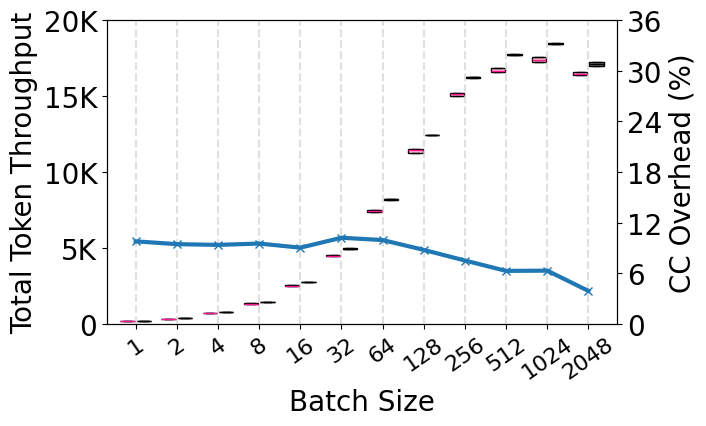

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker


def k_formatter(x, pos):
    if abs(x) < 1e-9:
        return "0"              # 0에는 K 안 붙이기
    return f"{x/1000:.0f}K"      # 혹은 .1f로 소수 한 자리까지
# Single model
model_order = ["meta-llama/Llama-3.1-8B"]

solid_thresholds = {
    model_order[0]: 2048,
}

# Create a single figure/axes
fig, ax1 = plt.subplots(figsize=(7.16, 4.6))

model = model_order[0]
model_df = vllm_dtx_df[vllm_dtx_df["model_path"] == model].copy()

# x-axis positions and labels
x_labels = model_df["max_num_seqs"].tolist()
base_pos = list(range(len(x_labels)))

# Build boxplot dicts
cc_boxes = []
noncc_boxes = []
for i in range(len(model_df)):
    cc_boxes.append({
        'med':    model_df.iloc[i]["mean_cc"],
        'q1':     model_df.iloc[i]["min_cc"],
        'q3':     model_df.iloc[i]["max_cc"],
        'whislo': model_df.iloc[i]["min_cc"],
        'whishi': model_df.iloc[i]["max_cc"],
        'fliers': []
    })
    noncc_boxes.append({
        'med':    model_df.iloc[i]["mean_noncc"],
        'q1':     model_df.iloc[i]["min_noncc"],
        'q3':     model_df.iloc[i]["max_noncc"],
        'whislo': model_df.iloc[i]["min_noncc"],
        'whishi': model_df.iloc[i]["max_noncc"],
        'fliers': []
    })

# Offsets for side-by-side boxes
cc_pos = [p - 0.2 for p in base_pos]
noncc_pos = [p + 0.2 for p in base_pos]

# Boxplots
ax1.bxp(
    cc_boxes, positions=cc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="pink"), medianprops=dict(color="deeppink")
)
ax1.bxp(
    noncc_boxes, positions=noncc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="gray"), medianprops=dict(color="black")
)

# X/Y formatting
ax1.set_xticks(base_pos)
ax1.set_xticklabels([str(x) for x in x_labels], rotation=35, fontsize=16)
ax1.xaxis.set_major_locator(ticker.FixedLocator(base_pos))  # prevent auto-skipping
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5000))
ax1.set_ylim(bottom=0, top=20000)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))

ax1.set_ylabel("Total Token Throughput", fontsize=20)
ax1.set_xlabel("Batch Size", fontsize=20)
#ax1.set_title(model.split('/')[-1], fontsize=20, fontweight="bold")
ax1.tick_params(axis='y', labelsize=20)

# Vertical guides
for pos in base_pos:
    ax1.axvline(x=pos, color="lightgray", linestyle="--", alpha=0.7)

# Secondary axis for CC Overhead (%)
ax2 = ax1.twinx()
threshold = solid_thresholds.get(model, 128)

df_solid = model_df[model_df["max_num_seqs"] <= threshold]
df_dashed = model_df[model_df["max_num_seqs"] > threshold]

if not df_solid.empty:
    x_solid = [x_labels.index(x) for x in df_solid["max_num_seqs"]]
    y_solid = (df_solid["cc_overhead"] - 1) * 100
    ax2.plot(x_solid, y_solid, linestyle='-', marker='x', linewidth=3, label="CC Overhead (≤ threshold)")

if not df_dashed.empty:
    x_dashed = [x_labels.index(x) for x in df_dashed["max_num_seqs"]]
    y_dashed = (df_dashed["cc_overhead"] - 1) * 100
    ax2.plot(x_dashed, y_dashed, linestyle='--', marker='x', linewidth=1, label="CC Overhead (> threshold)")

# Connect solid→dashed if both exist
if not df_solid.empty and not df_dashed.empty:
    last_x_solid = x_labels.index(df_solid["max_num_seqs"].max())
    first_x_dashed = x_labels.index(df_dashed["max_num_seqs"].min())
    last_y_solid = ((df_solid[df_solid["max_num_seqs"] == df_solid["max_num_seqs"].max()]["cc_overhead"].values[0]) - 1) * 100
    first_y_dashed = ((df_dashed[df_dashed["max_num_seqs"] == df_dashed["max_num_seqs"].min()]["cc_overhead"].values[0]) - 1) * 100
    ax2.plot([last_x_solid, first_x_dashed], [last_y_solid, first_y_dashed], linestyle="--", linewidth=1)

ax2.set_ylabel("CC Overhead (%)", fontsize=20)
ax2.set_ylim(bottom=0, top=36)
ax2.tick_params(axis='y', labelsize=20)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(6))

# Legends (combine CC/Non-CC boxes + overhead line)
# handles_boxes = [
#     plt.Line2D([], [], color="deeppink", label="CC"),
#     plt.Line2D([], [], color="black", label="Non-CC"),
# ]
# handles_lines, labels_lines = ax2.get_legend_handles_labels()
# all_handles = handles_boxes + handles_lines
# ax1.legend(all_handles, [h.get_label() for h in all_handles], loc='upper center', ncols=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1.10))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# SGLang TDX

In [54]:

# 개별 CSV 파일 읽기
df1 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-11-16/sglang_offline_nps4_cc_2025-11-16.csv")
df2 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-11-14/sglang_offline_nps4_cc_2025-11-14.csv")
#df3 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-11-12/sglang_offline_nps4_cc_2025-11-12.csv")
#df4 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-11-06/sglang_offline_nps4_cc_2025-11-06.csv")
df5 = pd.read_csv("./intel/sglang_offline_nps4_cc_5000_2025-11-18/sglang_offline_nps4_cc_2025-11-18.csv")
# 리스트에 추가
df_list = [df1, df2,df5]

# 병합
merged_df = pd.concat(df_list, ignore_index=True)

#merged_df=merged_df[['model_path','max_num_seqs','total_token_throughput']]
display(merged_df[(merged_df['model_path']=='meta-llama/Llama-3.1-8B') ])
output_csv = "sglang_tdx_offline_cc_merged.csv"
# 저장
merged_df.to_csv(output_csv, index=False)


,model_path,max_num_seqs,successful_requests,total_input_tokens,total_output_tokens,request_throughput,input_token_throughput,output_token_throughput,total_token_throughput,mean_e2e_latency,median_e2e_latency,p25_e2e_latency,p75_e2e_latency,p99_e2e_latency,mean_ttft,median_ttft,p25_ttft,p75_ttft,p99_ttft,mean_tpot,median_tpot,p25_tpot,p75_tpot,p99_tpot,mean_itl,median_itl,p25_itl,p75_itl,p99_itl
0,meta-llama/Llama-3.1-8B,2048,5000,640000,640000,66.79,8549.02,8549.02,17098.04,51267.52,53787.97,30953.43,66042.82,73671.35,29332.48,32640.52,8526.67,37983.12,59166.37,NaN,NaN,138.43,182.46,427.02,565.32,118.12,91.47,162.53,7768.08
1,meta-llama/Llama-3.1-8B,1024,5000,640000,640000,70.75,9056.09,9056.09,18112.19,42131.60,42274.81,29206.67,56420.37,69440.72,31626.85,31418.96,17566.81,45231.41,59971.30,NaN,NaN,69.39,92.88,109.94,501.60,73.47,64.40,83.85,8167.25
2,meta-llama/Llama-3.1-8B,512,5000,640000,640000,63.43,8119.34,8119.34,16238.68,43820.07,40758.00,25483.97,63753.60,77349.40,38000.69,35179.17,19330.23,57154.85,72895.56,NaN,NaN,43.38,52.13,59.46,426.95,39.78,34.85,45.84,1872.61
3,meta-llama/Llama-3.1-8B,256,5000,640000,640000,54.36,6958.39,6958.39,13916.77,48498.46,47097.14,25319.69,69436.45,90403.53,45074.86,43811.68,21827.90,66229.68,87899.94,NaN,NaN,26.15,30.97,35.13,419.05,25.34,22.96,27.50,685.92
4,meta-llama/Llama-3.1-8B,128,5000,640000,640000,41.04,5253.73,5253.73,10507.47,61630.92,61049.91,31291.20,91431.30,118885.65,59235.51,58502.42,28959.35,88816.93,116358.74,NaN,NaN,18.38,20.31,23.86,511.07,17.79,17.13,20.77,284.23
5,meta-llama/Llama-3.1-8B,64,5000,640000,640000,25.56,3271.14,3271.14,6542.28,96244.12,95835.64,48090.47,143344.19,192164.71,94178.14,93698.27,46120.59,141078.26,189885.78,NaN,NaN,15.58,17.88,18.05,778.55,15.77,15.12,18.56,53.36
6,meta-llama/Llama-3.1-8B,32,5000,640000,640000,14.89,1905.99,1905.99,3811.98,166162.71,165230.10,83350.66,249530.53,330578.40,164184.27,163167.82,81378.21,247443.21,328528.21,NaN,NaN,15.26,16.29,17.13,1332.53,14.62,14.22,15.18,90.52
7,meta-llama/Llama-3.1-8B,16,5000,640000,640000,8.30,1062.73,1062.73,2125.45,298592.85,297179.53,148368.52,448521.45,594786.30,296783.19,295320.93,146593.71,446663.48,592928.99,NaN,NaN,14.06,14.67,15.18,2389.78,13.85,13.42,14.27,61.26
8,meta-llama/Llama-3.1-8B,8,5000,640000,640000,4.44,568.82,568.82,1137.65,560974.23,559146.15,280267.41,842753.75,1112519.12,559246.49,557371.76,278351.54,841022.80,1110745.22,NaN,NaN,13.51,13.94,14.13,4487.52,13.60,13.20,13.97,42.03
9,meta-llama/Llama-3.1-8B,4,5000,640000,640000,2.31,295.82,295.82,591.63,1078024.92,1075193.96,533190.35,1622024.42,2140820.22,1076340.90,1073504.10,531512.55,1620319.22,2139120.42,NaN,NaN,13.11,13.49,15.61,8596.03,13.25,12.85,13.66,41.06


In [55]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("sglang_tdx_offline_cc_merged.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_cc='mean',
    min_cc='min',
    max_cc='max',
    std_dev_cc='std',
    cv_cc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("sglang_tdx_offline_cc_min_and_max.csv", index=False)
display(grouped)

,model_path,max_num_seqs,mean_cc,min_cc,max_cc,std_dev_cc,cv_cc
0,meta-llama/Llama-3.1-8B,1,154.725000,152.03,157.42,3.811306,0.024633
1,meta-llama/Llama-3.1-8B,2,305.635000,303.33,307.94,3.259762,0.010666
2,meta-llama/Llama-3.1-8B,4,598.550000,591.63,605.47,9.786358,0.016350
3,meta-llama/Llama-3.1-8B,8,1160.423333,1137.65,1185.24,23.860709,0.020562
4,meta-llama/Llama-3.1-8B,16,2156.456667,2125.45,2188.50,31.537781,0.014625
5,meta-llama/Llama-3.1-8B,32,3889.413333,3811.98,3930.68,67.107700,0.017254
6,meta-llama/Llama-3.1-8B,64,6657.900000,6542.28,6791.21,125.404299,0.018835
7,meta-llama/Llama-3.1-8B,128,10570.083333,10507.47,10680.45,95.868690,0.009070
8,meta-llama/Llama-3.1-8B,256,14057.533333,13916.77,14251.52,173.605683,0.012350
9,meta-llama/Llama-3.1-8B,512,16422.510000,16238.68,16608.59,184.965264,0.011263


In [47]:
import pandas as pd

# 개별 CSV 파일 읽기
df1 = pd.read_csv("./intel/sglang_offline_nps4_noncc_5000_2025-11-10/sglang_offline_nps4_noncc_2025-11-10.csv")
df2 = pd.read_csv("./intel/sglang_offline_nps4_noncc_5000_2025-11-13/sglang_offline_nps4_noncc_2025-11-13.csv")
df3 = pd.read_csv("./intel/sglang_offline_nps4_noncc_5000_2025-11-18/sglang_offline_nps4_noncc_2025-11-18.csv")
# 리스트에 추가
df_list = [df1,df2,df3]
# 병합
merged_df = pd.concat(df_list, ignore_index=True)
#merged_df=merged_df[['model_path','max_num_seqs','total_token_throughput']]
display(merged_df[(merged_df['model_path']=='meta-llama/Llama-3.1-8B')&(merged_df['max_num_seqs']==2048) ])
output_csv = "sglang_tdx_offline_noncc_merged.csv"
# 저장
merged_df.to_csv(output_csv, index=False)


,model_path,max_num_seqs,successful_requests,total_input_tokens,total_output_tokens,request_throughput,input_token_throughput,output_token_throughput,total_token_throughput,mean_e2e_latency,median_e2e_latency,p25_e2e_latency,p75_e2e_latency,p99_e2e_latency,mean_ttft,median_ttft,p25_ttft,p75_ttft,p99_ttft,mean_tpot,median_tpot,p25_tpot,p75_tpot,p99_tpot,mean_itl,median_itl,p25_itl,p75_itl,p99_itl
0,meta-llama/Llama-3.1-8B,2048,5000,640000,640000,28.84,3691.84,3691.84,7383.68,89490.80,88764.84,NaN,NaN,NaN,85579.95,85455.22,NaN,NaN,168985.76,NaN,NaN,NaN,NaN,NaN,30.80,11.46,NaN,NaN,18.72
12,meta-llama/Llama-3.1-8B,2048,5000,640000,640000,76.67,9813.76,9813.76,19627.52,44516.21,47189.81,NaN,NaN,NaN,25397.63,28426.64,NaN,NaN,51648.61,NaN,NaN,NaN,NaN,NaN,150.56,69.46,NaN,NaN,659.00
24,meta-llama/Llama-3.1-8B,2048,5000,640000,640000,76.74,9822.21,9822.21,19644.42,46780.70,50144.71,30145.06,57547.5,64185.72,25912.27,29819.19,7376.02,33442.56,51640.57,NaN,NaN,131.27,186.94,370.43,704.27,168.70,122.97,223.26,10375.70


In [49]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("./sglang_tdx_offline_noncc_merged.csv")


# 그룹화 및 통계 집계
grouped = df.groupby(['model_path', 'max_num_seqs'])['total_token_throughput'].agg(
    mean_noncc='mean',
    min_noncc='min',
    max_noncc='max',
    std_dev_noncc='std',
    cv_noncc=coefficient_of_variation
).reset_index()

# 결과 저장
grouped.to_csv("sglang_tdx_offline_noncc_min_and_max.csv", index=False)
print(grouped)

                 model_path  max_num_seqs    mean_noncc  min_noncc  max_noncc  \
0   meta-llama/Llama-3.1-8B             1    202.135000     201.80     202.47   
1   meta-llama/Llama-3.1-8B             2    397.410000     396.74     398.08   
2   meta-llama/Llama-3.1-8B             4    785.245000     784.40     786.09   
3   meta-llama/Llama-3.1-8B             8   1531.145000    1528.85    1533.44   
4   meta-llama/Llama-3.1-8B            16   2862.383333    2859.52    2866.64   
5   meta-llama/Llama-3.1-8B            32   5245.340000    5238.97    5252.71   
6   meta-llama/Llama-3.1-8B            64   8835.786667    8831.77    8843.71   
7   meta-llama/Llama-3.1-8B           128  13494.083333   13487.99   13504.35   
8   meta-llama/Llama-3.1-8B           256  17703.523333   17607.44   17885.95   
9   meta-llama/Llama-3.1-8B           512  19478.663333   19468.37   19486.81   
10  meta-llama/Llama-3.1-8B          1024  20172.513333   20123.88   20256.52   
11  meta-llama/Llama-3.1-8B 

In [6]:
import pandas as pd
from IPython.display import display

# 두 개의 CSV 파일 읽기
df1 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/sglang_tdx_offline_cc_min_and_max.csv")
df2 = pd.read_csv("/home/esp/SIGMETRICE-26-GPU-CC/offline/sglang_tdx_offline_noncc_min_and_max.csv")

# 병합
sglang_tdx_offline_df = pd.merge(df1, df2, on=['model_path', 'max_num_seqs'], how='inner')

# 오버헤드 계산
sglang_tdx_offline_df['cc_overhead'] = sglang_tdx_offline_df['mean_noncc'] / sglang_tdx_offline_df['mean_cc']
sglang_tdx_offline_df['min_cc_overhead'] = sglang_tdx_offline_df['min_noncc'] / sglang_tdx_offline_df['min_cc']
sglang_tdx_offline_df['max_cc_overhead'] = sglang_tdx_offline_df['max_noncc'] / sglang_tdx_offline_df['max_cc']



# 표 형태로 출력
display(sglang_tdx_offline_df[['model_path', 'max_num_seqs', 'mean_cc', 
                               'mean_noncc','cv_cc', 'cv_noncc','cc_overhead']])


,model_path,max_num_seqs,mean_cc,mean_noncc,cv_cc,cv_noncc,cc_overhead
0,meta-llama/Llama-3.1-8B,1,154.725000,202.135000,0.024633,0.002344,1.306415
1,meta-llama/Llama-3.1-8B,2,305.635000,397.410000,0.010666,0.002384,1.300276
2,meta-llama/Llama-3.1-8B,4,598.550000,785.245000,0.016350,0.001522,1.311912
3,meta-llama/Llama-3.1-8B,8,1160.423333,1531.145000,0.020562,0.002120,1.319471
4,meta-llama/Llama-3.1-8B,16,2156.456667,2862.383333,0.014625,0.001313,1.327355
5,meta-llama/Llama-3.1-8B,32,3889.413333,5245.340000,0.017254,0.001320,1.348620
6,meta-llama/Llama-3.1-8B,64,6657.900000,8835.786667,0.018835,0.000777,1.327113
7,meta-llama/Llama-3.1-8B,128,10570.083333,13494.083333,0.009070,0.000663,1.276630
8,meta-llama/Llama-3.1-8B,256,14057.533333,17703.523333,0.012350,0.008928,1.259362
9,meta-llama/Llama-3.1-8B,512,16422.510000,19478.663333,0.011263,0.000483,1.186095


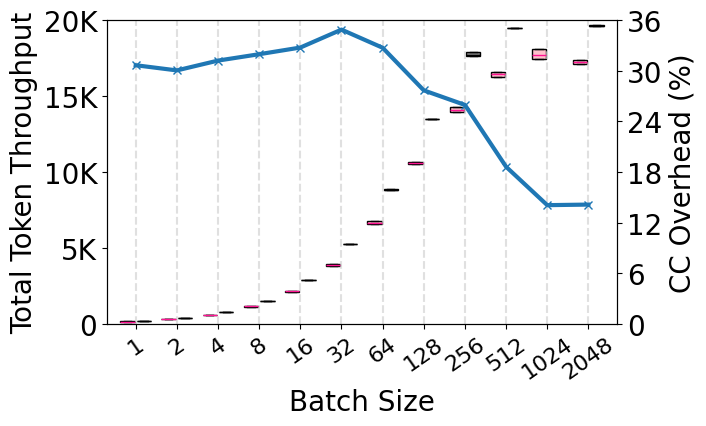

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker


def k_formatter(x, pos):
    if abs(x) < 1e-9:
        return "0"              # 0에는 K 안 붙이기
    return f"{x/1000:.0f}K"      # 혹은 .1f로 소수 한 자리까지
# Single model
model_order = ["meta-llama/Llama-3.1-8B"]

solid_thresholds = {
    model_order[0]: 2048,
}

# Create a single figure/axes
fig, ax1 = plt.subplots(figsize=(7.16, 4.6))

model = model_order[0]
model_df = sglang_tdx_offline_df[sglang_tdx_offline_df["model_path"] == model].copy()

# x-axis positions and labels
x_labels = model_df["max_num_seqs"].tolist()
base_pos = list(range(len(x_labels)))

# Build boxplot dicts
cc_boxes = []
noncc_boxes = []
for i in range(len(model_df)):
    cc_boxes.append({
        'med':    model_df.iloc[i]["mean_cc"],
        'q1':     model_df.iloc[i]["min_cc"],
        'q3':     model_df.iloc[i]["max_cc"],
        'whislo': model_df.iloc[i]["min_cc"],
        'whishi': model_df.iloc[i]["max_cc"],
        'fliers': []
    })
    noncc_boxes.append({
        'med':    model_df.iloc[i]["mean_noncc"],
        'q1':     model_df.iloc[i]["min_noncc"],
        'q3':     model_df.iloc[i]["max_noncc"],
        'whislo': model_df.iloc[i]["min_noncc"],
        'whishi': model_df.iloc[i]["max_noncc"],
        'fliers': []
    })

# Offsets for side-by-side boxes
cc_pos = [p - 0.2 for p in base_pos]
noncc_pos = [p + 0.2 for p in base_pos]

# Boxplots
ax1.bxp(
    cc_boxes, positions=cc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="pink"), medianprops=dict(color="deeppink")
)
ax1.bxp(
    noncc_boxes, positions=noncc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="gray"), medianprops=dict(color="black")
)

# X/Y formatting
ax1.set_xticks(base_pos)
ax1.set_xticklabels([str(x) for x in x_labels], rotation=35, fontsize=16)
ax1.xaxis.set_major_locator(ticker.FixedLocator(base_pos))  # prevent auto-skipping
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5000))
ax1.set_ylim(bottom=0, top=20000)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))

ax1.set_ylabel("Total Token Throughput", fontsize=20)
ax1.set_xlabel("Batch Size", fontsize=20)
#ax1.set_title(model.split('/')[-1], fontsize=20, fontweight="bold")
ax1.tick_params(axis='y', labelsize=20)

# Vertical guides
for pos in base_pos:
    ax1.axvline(x=pos, color="lightgray", linestyle="--", alpha=0.7)

# Secondary axis for CC Overhead (%)
ax2 = ax1.twinx()
threshold = solid_thresholds.get(model, 128)

df_solid = model_df[model_df["max_num_seqs"] <= threshold]
df_dashed = model_df[model_df["max_num_seqs"] > threshold]

if not df_solid.empty:
    x_solid = [x_labels.index(x) for x in df_solid["max_num_seqs"]]
    y_solid = (df_solid["cc_overhead"] - 1) * 100
    ax2.plot(x_solid, y_solid, linestyle='-', marker='x', linewidth=3, label="CC Overhead (≤ threshold)")

if not df_dashed.empty:
    x_dashed = [x_labels.index(x) for x in df_dashed["max_num_seqs"]]
    y_dashed = (df_dashed["cc_overhead"] - 1) * 100
    ax2.plot(x_dashed, y_dashed, linestyle='--', marker='x', linewidth=1, label="CC Overhead (> threshold)")

# Connect solid→dashed if both exist
if not df_solid.empty and not df_dashed.empty:
    last_x_solid = x_labels.index(df_solid["max_num_seqs"].max())
    first_x_dashed = x_labels.index(df_dashed["max_num_seqs"].min())
    last_y_solid = ((df_solid[df_solid["max_num_seqs"] == df_solid["max_num_seqs"].max()]["cc_overhead"].values[0]) - 1) * 100
    first_y_dashed = ((df_dashed[df_dashed["max_num_seqs"] == df_dashed["max_num_seqs"].min()]["cc_overhead"].values[0]) - 1) * 100
    ax2.plot([last_x_solid, first_x_dashed], [last_y_solid, first_y_dashed], linestyle="--", linewidth=1)

ax2.set_ylabel("CC Overhead (%)", fontsize=20)
ax2.set_ylim(bottom=0, top=36)
ax2.tick_params(axis='y', labelsize=20)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(6))

# Legends (combine CC/Non-CC boxes + overhead line)
# handles_boxes = [
#     plt.Line2D([], [], color="deeppink", label="CC"),
#     plt.Line2D([], [], color="black", label="Non-CC"),
# ]
# handles_lines, labels_lines = ax2.get_legend_handles_labels()
# all_handles = handles_boxes + handles_lines
# ax1.legend(all_handles, [h.get_label() for h in all_handles], loc='upper center', ncols=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1.10))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
